# Лабораторная работа 3. Классификация. Нейронные сети

## Описание работы

**Цель работы:** изучение методов классификации данных, реализованные в библиотеке Scikit-Learn, а также ознакомление с нейронными сетями с использованием библиотек TensorFlow и TensorBoard.

**Постановка задачи:**

1. Необходимо выбрать и подготовить датасет для классификации, затем построить классификационные модели с помощью пяти методов:

    - Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB);

    - Деревья решений (Decision Tree);

    - Линейный дискриминантный анализ (Linear Discriminant Analysis);

    - Метод опорных векторов (Support Vector Machines);

    - Метод ближайших соседей (k-Nearest Neighbors);

2. Затем сравните качество работы классификаторов с помощью следующих метрик:

    - Accuracy (точность),

    - Precision (доля правильно классифицированных положительных примеров),

    - Recall (чувствительность, доля верно найденных положительных примеров),

    - F1-Score (среднее гармоническое precision и recall),

    - Площадь под кривой ROC (AUC-ROC).

3. Настройте гиперпараметры каждого метода и проведите исследование влияния различных параметров на качество классификации.

4. Реализуйте и протестируйте нейронную сеть на TensorFlow, исследуйте эффект настройки гиперпараметров и визуализируйте процесс обучения с помощью инструмента TensorBoard.

## Ход работы

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('datasets/Titanic-Dataset.csv')

data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

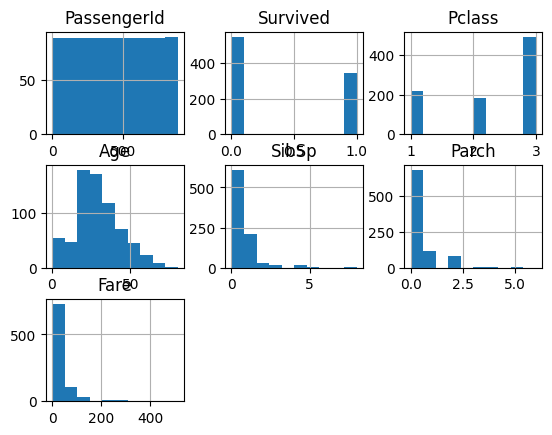

In [22]:
data.info()

data.hist()

In [23]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
data.drop(labels='Cabin', inplace=True, axis=1)
data.drop(labels='Name', inplace=True, axis=1)
data.drop(labels='Ticket', inplace=True, axis=1)
data.drop(labels='PassengerId', inplace=True, axis=1)
data['Age'] = data['Age'].fillna(data['Age'].median())

data['Embarked'] = data['Embarked'].fillna('S')



data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [25]:
data.Embarked.value_counts()


Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>],
       [<Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

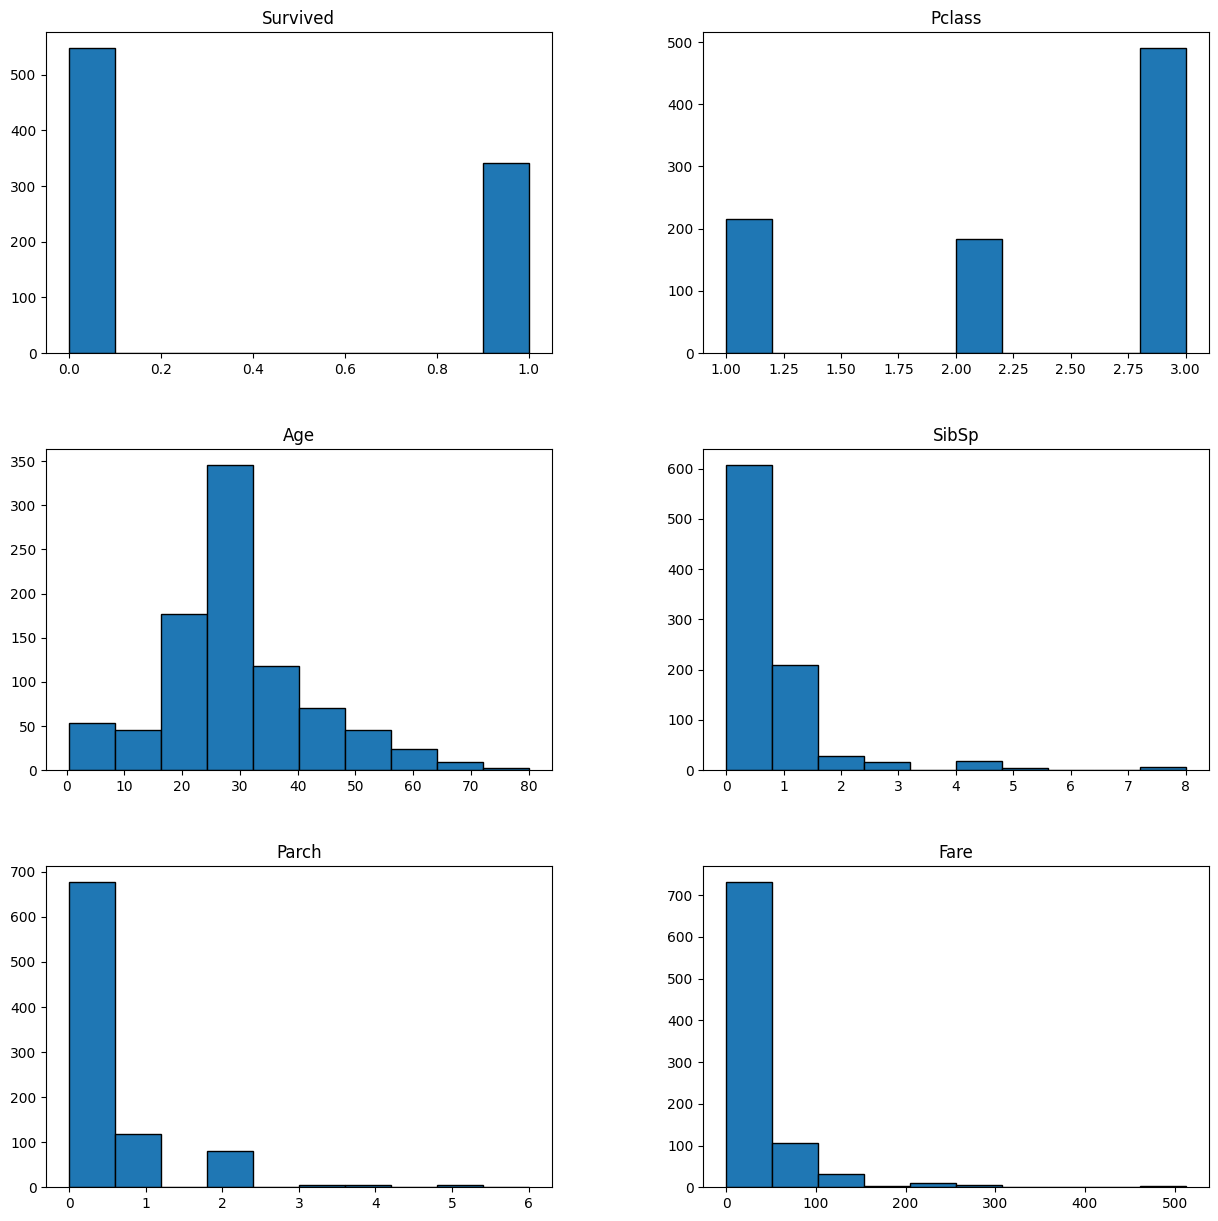

In [26]:
data.hist(edgecolor='black',  figsize=(15, 15), grid=False)

Text(0.5, 1.0, 'Embarked')

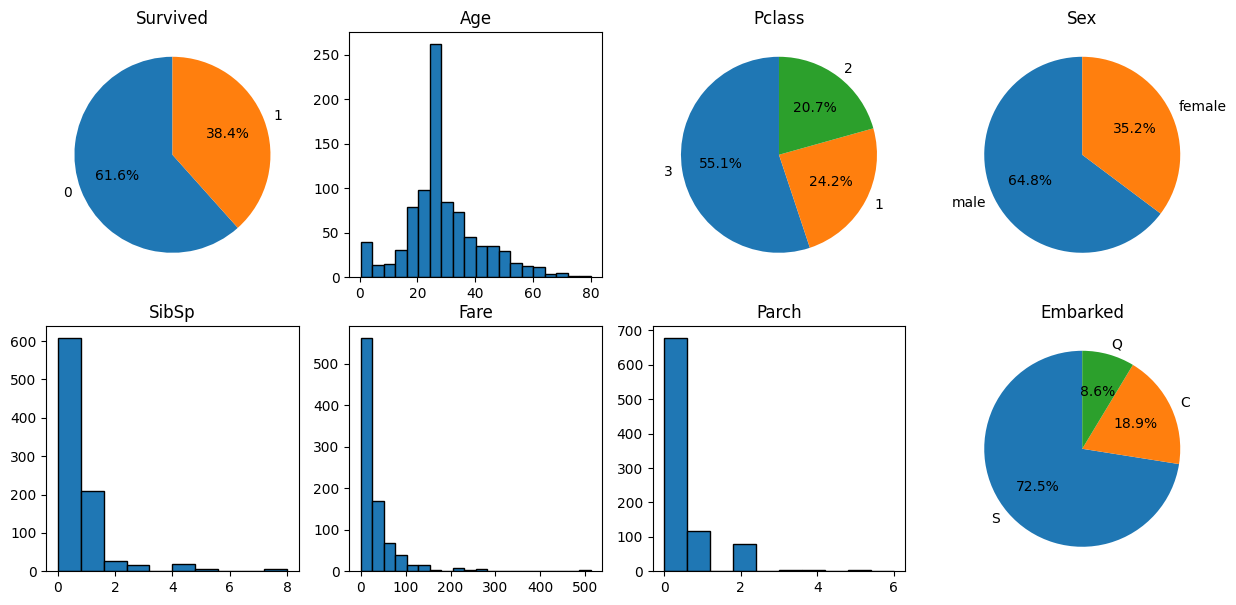

In [27]:
fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize = (15,7))

ax[0,0].pie(data.Survived.value_counts(), labels= data.Survived.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[0,0].set_title('Survived')


ax[0, 1].hist(data.Age, bins=20, edgecolor='black')
ax[0, 1].set_title('Age')

ax[0,2].pie(data.Pclass.value_counts(), labels= data.Pclass.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[0, 2].set_title('Pclass')

ax[0,3].pie(data.Sex.value_counts(), labels= data.Sex.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[0, 3].set_title('Sex')

ax[1,0].hist(data.SibSp, edgecolor='black')
ax[1, 0].set_title('SibSp')

ax[1, 1].hist(data.Fare, bins=20, edgecolor='black')
ax[1, 1].set_title('Fare')

ax[1,2].hist(data.Parch, edgecolor='black')
ax[1, 2].set_title('Parch')

ax[1,3].pie(data.Embarked.value_counts(), labels= data.Embarked.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[1, 3].set_title('Embarked')

In [28]:
data['Embarked'] = data['Embarked'].fillna('Missing')


In [29]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [30]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num = data.drop(['Embarked', 'Sex'], axis=1)
data_scaled = pd.DataFrame(
    scaler.fit_transform(num),
    columns=num.columns,
    index=data.index
)
data_scaled = pd.concat([data_scaled, pd.get_dummies(data.Embarked, drop_first=False, dtype='int8'), pd.get_dummies(data.Sex, drop_first=False, dtype='int8')], axis=1)
data_scaled.round(2)


,Survived,Pclass,Age,SibSp,Parch,Fare,C,Q,S,female,male
0,-0.79,0.83,-0.57,0.43,-0.47,-0.50,0,0,1,0,1
1,1.27,-1.57,0.66,0.43,-0.47,0.79,1,0,0,1,0
2,1.27,0.83,-0.26,-0.47,-0.47,-0.49,0,0,1,1,0
3,1.27,-1.57,0.43,0.43,-0.47,0.42,0,0,1,1,0
4,-0.79,0.83,0.43,-0.47,-0.47,-0.49,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,-0.79,-0.37,-0.18,-0.47,-0.47,-0.39,0,0,1,0,1
887,1.27,-1.57,-0.80,-0.47,-0.47,-0.04,0,0,1,1,0
888,-0.79,0.83,-0.10,0.43,2.01,-0.18,0,0,1,1,0
889,1.27,-1.57,-0.26,-0.47,-0.47,-0.04,1,0,0,0,1


In [31]:

from sklearn.model_selection import train_test_split

X = data_scaled.drop(['Survived'], axis=1)

y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB)

In [32]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

model_nb = GaussianNB()

model_nb.fit(X_train, y_train)

y_predNB = model_nb.predict(X_test)


print(confusion_matrix(y_test, y_predNB))
accuracyNB = accuracy_score(y_test, y_predNB)
recallNB = recall_score(y_test, y_predNB)
precisionNB = precision_score(y_test, y_predNB)
f1NB = f1_score(y_test, y_predNB)
roc_aucNB = roc_auc_score(y_test, y_predNB)
accuracyNB



[[143  32]
 [ 28  92]]


0.7966101694915254

### Деревья решений (Decision Tree)

[[157  18]
 [ 35  85]]


0.8203389830508474

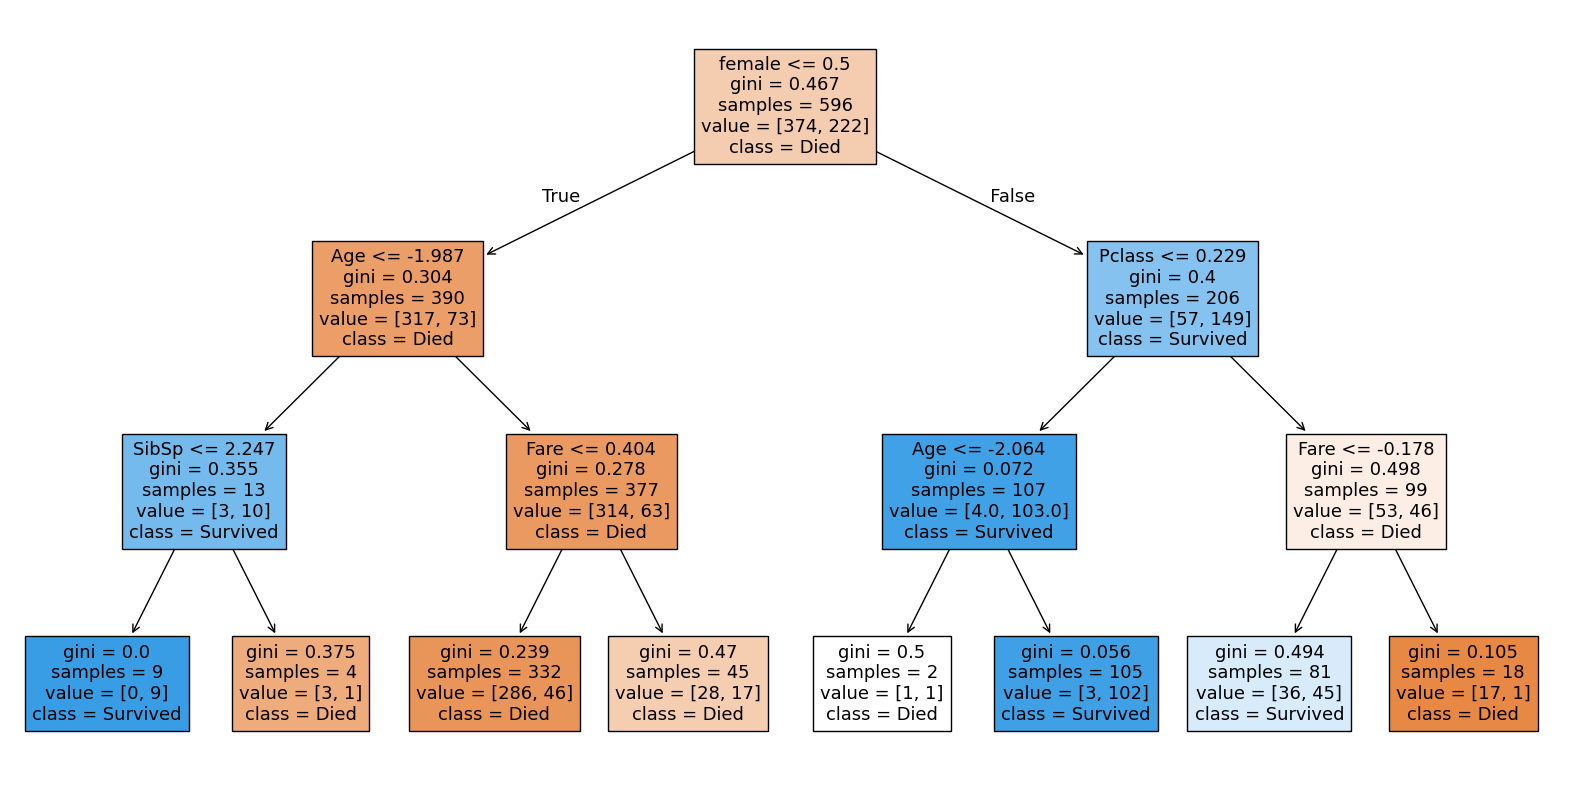

In [33]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

model_tree = DecisionTreeClassifier(
    max_depth=3
)

model_tree.fit(X_train, y_train)

y_predTree = model_tree.predict(X_test)

print(confusion_matrix(y_test, y_predTree))
accuracyTree = accuracy_score(y_test, y_predTree)
recallTree = recall_score(y_test, y_predTree)
precisionTree = precision_score(y_test, y_predTree)
f1Tree = f1_score(y_test, y_predTree)
roc_aucTree = roc_auc_score(y_test, y_predTree)

plt.figure(figsize=(20,10))
plot_tree(model_tree,
    filled=True,
    feature_names=X.columns,
    class_names=['Died', 'Survived']
    )
accuracyTree

### Линейный дискриминантный анализ (Linear Discriminant Analysis)


In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

model_LDA = LinearDiscriminantAnalysis()

model_LDA.fit(X_train, y_train)

y_predLDA = model_LDA.predict(X_test)

print(confusion_matrix(y_test, y_predLDA))

accuracyLDA = accuracy_score(y_test, y_predLDA)
recallLDA = recall_score(y_test, y_predLDA)
precisionLDA = precision_score(y_test, y_predLDA)
f1LDA = f1_score(y_test, y_predLDA)
roc_aucLDA = roc_auc_score(y_test, y_predLDA)

accuracyLDA

[[150  25]
 [ 36  84]]


0.7932203389830509

### Метод опорных векторов (Support Vector Machines)

In [35]:
from sklearn.svm import SVC

model_SVM = SVC(
    gamma = 'auto'
)

model_SVM.fit(X_train, y_train)

y_predSVM = model_SVM.predict(X_test)

print(confusion_matrix(y_test, y_predSVM))

accuracySVM = accuracy_score(y_test, y_predSVM)
recallSVM = recall_score(y_test, y_predSVM)
precisionSVM = precision_score(y_test, y_predSVM)
f1SVM = f1_score(y_test, y_predSVM)
roc_aucSVM = roc_auc_score(y_test, y_predSVM)

accuracySVM

[[158  17]
 [ 30  90]]


0.8406779661016949

### Метод ближайших соседей (k-Nearest Neighbors)

In [36]:
from sklearn.neighbors import KNeighborsClassifier

model_KN = KNeighborsClassifier()

model_KN.fit(X_train, y_train)

y_predKN = model_KN.predict(X_test)

print(confusion_matrix(y_test, y_predKN))

accuracyKN = accuracy_score(y_test, y_predKN)
recallKN = recall_score(y_test, y_predKN)
precisionKN = precision_score(y_test, y_predKN)
f1KN = f1_score(y_test, y_predKN)
roc_aucKN = roc_auc_score(y_test, y_predKN)

accuracyKN


[[154  21]
 [ 39  81]]


0.7966101694915254

In [37]:
rows = [
    {'model': 'Naive Bayes', 'accuracy': accuracyNB, 'recall': recallNB, 'precision': precisionNB, 'f1': f1NB, 'roc': roc_aucNB},
    {'model': 'Decision Tree', 'accuracy': accuracyTree, 'recall': recallTree, 'precision': precisionTree, 'f1': f1Tree, 'roc': roc_aucTree},
    {'model': 'LDA', 'accuracy': accuracyLDA, 'recall': recallLDA, 'precision': precisionLDA, 'f1': f1LDA, 'roc': roc_aucLDA},
    {'model': 'SVM', 'accuracy': accuracySVM, 'recall': recallSVM, 'precision': precisionSVM, 'f1': f1SVM, 'roc': roc_aucSVM},
    {'model': 'KNN', 'accuracy': accuracyKN, 'recall': recallKN, 'precision': precisionKN, 'f1': f1KN, 'roc': roc_aucKN},
]
model_data = pd.DataFrame(rows, columns=['model','accuracy','recall','precision','f1','roc'])

model_data

,model,accuracy,recall,precision,f1,roc
0,Naive Bayes,0.796610,0.766667,0.741935,0.754098,0.791905
1,Decision Tree,0.820339,0.708333,0.825243,0.762332,0.802738
2,LDA,0.793220,0.700000,0.770642,0.733624,0.778571
3,SVM,0.840678,0.750000,0.841121,0.792952,0.826429
4,KNN,0.796610,0.675000,0.794118,0.729730,0.777500


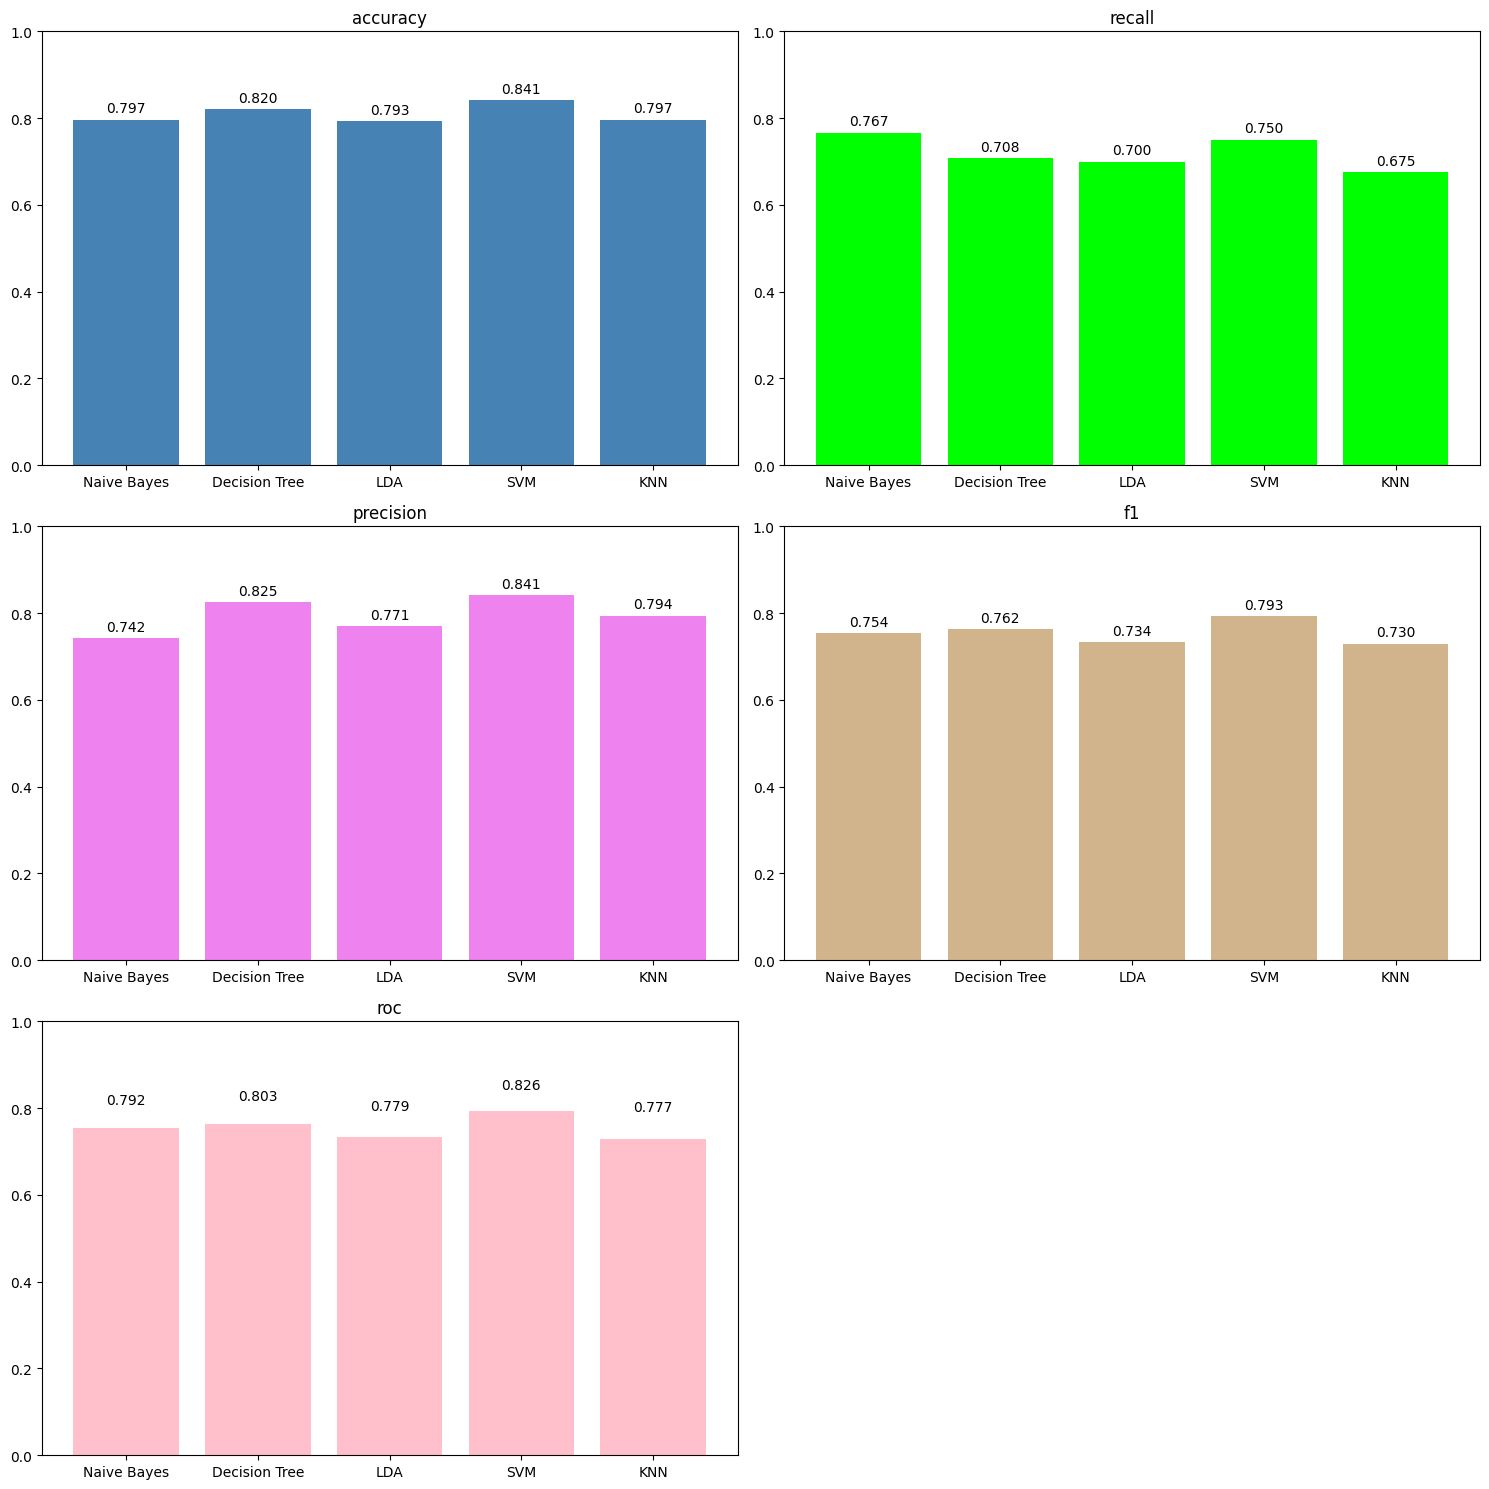

In [38]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (15,15))

ax[0,0].bar(model_data['model'], model_data['accuracy'], color='steelblue')
for i, v in enumerate(model_data['accuracy']):
    ax[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
ax[0,0].set_ylim(0,1)
ax[0,0].set_title('accuracy')

ax[0,1].bar(model_data['model'], model_data['recall'], color='lime')
ax[0,1].set_ylim(0,1)
ax[0,1].set_title('recall')
for i, v in enumerate(model_data['recall']):
    ax[0,1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

ax[1,0].bar(model_data['model'], model_data['precision'], color='violet')
ax[1,0].set_ylim(0,1)
ax[1,0].set_title('precision')
for i, v in enumerate(model_data['precision']):
    ax[1,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

ax[1,1].bar(model_data['model'], model_data['f1'], color='tan')
ax[1,1].set_ylim(0,1)
ax[1,1].set_title('f1')
for i, v in enumerate(model_data['f1']):
    ax[1,1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

ax[2,0].bar(model_data['model'], model_data['f1'], color='pink')
ax[2,0].set_ylim(0,1)
ax[2,0].set_title('roc')
for i, v in enumerate(model_data['roc']):
    ax[2,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

ax[2,1].set_visible(False)

plt.tight_layout()

In [39]:

print(np.array(X_train))

[[-1.56610693  1.89345853 -0.4745452  ...  1.          0.
   1.        ]
 [ 0.82737724 -0.1046374  -0.4745452  ...  0.          0.
   1.        ]
 [-0.36936484 -0.33518693  0.43279337 ...  0.          0.
   1.        ]
 ...
 [ 0.82737724  0.89441056  1.34013193 ...  1.          0.
   1.        ]
 [-1.56610693 -1.18053521  0.43279337 ...  1.          1.
   0.        ]
 [-1.56610693 -0.6425863  -0.4745452  ...  1.          0.
   1.        ]]


In [ ]:

import tensorflow as tf
import keras


model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation=keras.activations.relu),
    keras.layers.Dense(32, activation=keras.activations.relu),
    keras.layers.Dense(1, activation=keras.activations.sigmoid)
])

model.compile(
    optimizer='adam',
    loss = keras.losses.binary_crossentropy,
    metrics=[
        keras.metrics.BinaryAccuracy()
    ]
)


history = model.fit(
    np.array(X_train),
    np.array(y_train), 
    epochs=10, 
)

predictions = model.predict(X_test)

binary_predict = (predictions > 0.5).astype(int)

binary_predict


print(confusion_matrix(y_test, binary_predict))




Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6628 - loss: 0.6342  
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7064 - loss: 0.5667 
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7567 - loss: 0.5202 
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8087 - loss: 0.4848 
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8020 - loss: 0.4608 
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8154 - loss: 0.4444 
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8138 - loss: 0.4353 
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8171 - loss: 0.4286 
Epoch 9/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8188 - loss: 0.4236 
Epoch 10/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8238 - loss: 0.4178 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[[150  25]
 [ 30  90]]
